In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, make_scorer
import json
import shap
from sklearn.model_selection import cross_validate

def weighted_kmeans_clustering(df, k=10, location_vars=None, weights=None, size_var=None, id_col=None, random_state=42, max_iterations=100, verbose=None, init_centroids=None):
    """
    Desc: weighted K-means clustering to nearest centroid.
    
    ==========
    Parameters
    ==========
    df              : The dataframe containing data
    k               : Number of clusters to create
    location_vars   : List of column to use as location variables (default: all numeric columns)
    weights         : Variable used as weights (default: equal weights)
    size_var        : Column name to use for size weighting (default: None = equal weights of 1)
    id_col          : Column name for observation identification (default: None = use dataframe index)
    random_state    : Random seed
    max_iterations  : Maximum iterations
    verbose         : None (no output), 1 (summary only), 2 (full details)
    init_centroids  : data points (ex: [0, 5, 10]) or None for random initialization

    ==========
    Returns
    ==========
    cluster representatives dataframe
    """

    df = df.copy()

    # default size variable (all equal weights)
    if size_var is None:
        df['_temp_size_weight'] = 1.0
        size_var = '_temp_size_weight'
    
    # default id column (use index)
    if id_col is None:
        df['_temp_id'] = df.index
        id_col = '_temp_id'

    # determine which columns to use for clustering
    if location_vars is None:
        location_vars = df.select_dtypes(include=[np.number]).columns.tolist()
        # Remove size and id columns if they're in the numeric columns
        for col in [size_var, id_col, '_temp_size_weight', '_temp_id']:
            if col in location_vars:
                location_vars.remove(col)
            
    # set default weights (all features equally important)
    if weights is None:
        weights = {var: 1.0 for var in location_vars}
    
    # extract and standardize location data
    X_raw = df[location_vars].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    X_scaled_df = pd.DataFrame(X_scaled, columns=location_vars)
    
    # apply weights
    for var in location_vars:
        if var in weights:
            X_scaled_df[var] = X_scaled_df[var] * weights[var]
    
    X = X_scaled_df.values
    n_observations = len(X)

    # observation sizes and normalize weights
    size_weights = df[size_var].values
    normalized_weights = size_weights / size_weights.sum() * len(size_weights)
    

    # Initialize centroids
    if init_centroids is None:
        # random initialization
        np.random.seed(random_state)
        indices = np.random.choice(n_observations, k, replace=False)
        centroids = X[indices]
        init_method = "random"
    elif isinstance(init_centroids, list) and len(init_centroids) == k:
        # data points initialization
        indices = np.array(init_centroids)
        if np.any(indices >= n_observations) or np.any(indices < 0):
            raise ValueError(f"Initial centroid indices must be between 0 and {n_observations-1}")
        centroids = X[indices]
        init_method = "indices"
    else:
        raise ValueError(f"init_centroids must be None (random initialization) or a list of indices (ex: [0, 5, 10]) of length k={k}")
    
    if verbose is not None:
        print("=" * 50)
        print(f"INITIALIZATION")
        print("=" * 50)
        print(f"Number of clusters (k): {k}")
        print(f"Number of observations: {n_observations}")
        print(f"Number of features: {len(location_vars)}")
        print(f"Feature names: {location_vars}")
        print(f"Feature weights: {weights}")
        print(f"Initialization method: {init_method}")
        print(f"Random seed: {random_state}")
        print(f"Initial centroid indices: {indices}")
        if verbose >= 2:
            print(f"\nInitial centroid:")
            for i, centroid in enumerate(centroids):
                print(f"  Cluster {i}: {centroid}")
        print()
    
    # K-means iterations
    for iteration in range(max_iterations):
        # Calculate distance from each observation to each centroid
        distances = np.zeros((n_observations, k))
        
        for centroid_idx in range(k):
            centroid_position = centroids[centroid_idx]
            
            # calculate distance from each observation to this centroid
            for obs_idx in range(n_observations):
                obs_position = X[obs_idx]
                squared_differences = (obs_position - centroid_position) ** 2
                distance = np.sqrt(squared_differences.sum())
                distances[obs_idx, centroid_idx] = distance
        
        # assign each observation to nearest centroid
        labels = np.argmin(distances, axis=1)
        
        # Update centroids using weighted average
        new_centroids = np.zeros_like(centroids)
        
        for cluster_id in range(k):
            observations_in_cluster = (labels == cluster_id)
            
            if np.sum(observations_in_cluster) > 0:
                # calculate weighted average position of all observations in cluster
                cluster_points = X[observations_in_cluster]
                cluster_weights = normalized_weights[observations_in_cluster]
                new_centroids[cluster_id] = np.average(cluster_points, axis=0, weights=cluster_weights)
            else:
                # keep old centroid if cluster is empty
                new_centroids[cluster_id] = centroids[cluster_id]
        
        # convergence
        if verbose is not None:
            cluster_sizes = np.bincount(labels, minlength=k)
            print(f"Iteration {iteration + 1}:")
            print(f"  Cluster sizes: {cluster_sizes}")
            if verbose >= 2:
                print(f"New centroid positions:")
                for i, centroid in enumerate(new_centroids):
                    print(f"  Cluster {i}: {centroid}")
            print()
        
        if np.array_equal(new_centroids, centroids):
            if verbose is not None:
                print(f"Converged after {iteration + 1} iterations")
                print("=" * 50)
            break
        
        centroids = new_centroids
    else:
        if verbose is not None:
            print(f"Not converged after maximum iteration of = ({max_iterations})")
            print("=" * 50)
    
# find representative seriatim (nearest to centroid)
    df['cluster'] = labels
    representatives = []
    
    for cluster_id in range(k):
        observations_in_cluster = (labels == cluster_id)
        
        if np.sum(observations_in_cluster) > 0:
            # calculate distances from all points in a cluster to its centroid
            cluster_distances = np.linalg.norm(X[observations_in_cluster] - centroids[cluster_id], axis=1)
            
            # find observation with minimum distance
            closest_idx = np.where(observations_in_cluster)[0][np.argmin(cluster_distances)]
            cluster_weight_sum = df.loc[observations_in_cluster, size_var].sum()
            
            rep_info = {
                'cluster': cluster_id,
                'id': df.iloc[closest_idx][id_col],
                'cluster_size': np.sum(observations_in_cluster),
                'cluster_weight_sum': cluster_weight_sum
            }
            representatives.append(rep_info)
    
    return pd.DataFrame(representatives)

In [2]:
df = pd.read_excel('./SHEETS/k-means testing.xlsx', sheet_name='data_sample')
df = df.drop(columns=['No', 'cluster'])

result = weighted_kmeans_clustering(
    df=df,
    k=3,
    location_vars=['var_1', 'var_3'],
    weights={'var_1': 1, 'var_3': 1},
    random_state=42,
    verbose=2,
    init_centroids=[7, 8, 9]
)

print(result)


INITIALIZATION
Number of clusters (k): 3
Number of observations: 10
Number of features: 2
Feature names: ['var_1', 'var_3']
Feature weights: {'var_1': 1, 'var_3': 1}
Initialization method: indices
Random seed: 42
Initial centroid indices: [7 8 9]

Initial centroid:
  Cluster 0: [-0.41904997  1.35710229]
  Cluster 1: [-0.19253647 -1.1874645 ]
  Cluster 2: [-0.36242159 -1.61155897]

Iteration 1:
  Cluster sizes: [4 5 1]
New centroid positions:
  Cluster 0: [-0.68803474  0.93300782]
  Cluster 1: [ 0.62291211 -0.42409446]
  Cluster 2: [-0.36242159 -1.61155897]

Iteration 2:
  Cluster sizes: [5 3 2]
New centroid positions:
  Cluster 0: [-0.73616886  0.67855114]
  Cluster 1: [ 1.41193412 -0.19791075]
  Cluster 2: [-0.27747903 -1.39951173]

Iteration 3:
  Cluster sizes: [5 3 2]
New centroid positions:
  Cluster 0: [-0.73616886  0.67855114]
  Cluster 1: [ 1.41193412 -0.19791075]
  Cluster 2: [-0.27747903 -1.39951173]

Converged after 3 iterations
   cluster   id  cluster_size  cluster_weight_s

In [3]:
df = pd.read_excel('./SHEETS/k-means testing.xlsx', sheet_name='data_sample')
df = df.drop(columns=['No', 'cluster'])

result = weighted_kmeans_clustering(
    df=df,
    k=3,
    location_vars=['var_1', 'var_3'],
    weights={'var_1': 1, 'var_3': 3},
    random_state=42,
    verbose=2,
    init_centroids=[1, 5, 9]
)

print(result)


INITIALIZATION
Number of clusters (k): 3
Number of observations: 10
Number of features: 2
Feature names: ['var_1', 'var_3']
Feature weights: {'var_1': 1, 'var_3': 3}
Initialization method: indices
Random seed: 42
Initial centroid indices: [1 5 9]

Initial centroid:
  Cluster 0: [-0.92870533 -1.01782672]
  Cluster 1: [1.78945661 0.25445668]
  Cluster 2: [-0.36242159 -4.8346769 ]

Iteration 1:
  Cluster sizes: [4 4 2]
New centroid positions:
  Cluster 0: [-0.53230671 -0.38168502]
  Cluster 1: [0.67104623 2.48095262]
  Cluster 2: [-0.27747903 -4.1985352 ]

Iteration 2:
  Cluster sizes: [4 3 3]
New centroid positions:
  Cluster 0: [ 0.44453273 -0.06361417]
  Cluster 1: [-0.62668734  3.6472124 ]
  Cluster 2: [ 0.03397702 -3.5623935 ]

Iteration 3:
  Cluster sizes: [5 2 3]
New centroid positions:
  Cluster 0: [0.15855945 0.25445668]
  Cluster 1: [-0.44736415  4.70744856]
  Cluster 2: [ 0.03397702 -3.5623935 ]

Iteration 4:
  Cluster sizes: [5 2 3]
New centroid positions:
  Cluster 0: [0.1585

In [4]:
# Get only the representative indices from the result
representative_indices = result['id'].dropna().astype(int).tolist()

# Filter the original dataframe to keep only representatives
df_representatives = df.loc[representative_indices].copy()

# Add cluster and cluster_size information
cluster_size_map = dict(zip(result['cluster'], result['cluster_size']))
id_to_cluster = dict(zip(result['id'], result['cluster']))

df_representatives['cluster'] = df_representatives.index.map(id_to_cluster)
df_representatives['cluster_size'] = df_representatives['cluster'].map(cluster_size_map)
df_representatives = df_representatives.drop('cluster', axis=1)

print(df_representatives)

   var_1  var_2  var_3  cluster_size
0    300     30  50000             5
6   1000     20  90000             2
8   1500     30  20000             3


In [5]:
with open("PROCESSED/DATA/merged_and_dropped.cat_cols.json") as f:
    cat_cols = json.load(f)

X_train = pd.read_parquet("INPUTS/TRAIN/X_train.parquet")
X_test = pd.read_parquet("INPUTS/TEST/X_test.parquet")
y_train = pd.read_parquet("INPUTS/TRAIN/y_train.parquet")
y_test = pd.read_parquet("INPUTS/TEST/y_test.parquet")

X_train[cat_cols] = X_train[cat_cols].astype("category")
X_test[cat_cols] = X_test[cat_cols].astype("category")

num_cols = [c for c in X_train.columns if c not in cat_cols]

# encode
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# target
y_train_cat = y_train.iloc[:, 0].astype(int)
y_test_cat  = y_test.iloc[:, 0].astype(int)

# target
y_train_cat = y_train.iloc[:, 0].astype(int)
y_test_cat  = y_test.iloc[:, 0].astype(int)

# best parameters
with open("RESULTS/BASELINES/PARAMETERS/XGBClassifier_BEST_HYPER.json") as f:
    xgb_param = json.load(f)

# model with best parameters
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    **xgb_param
)

# cross-validation
scoring = {'accuracy': 'accuracy',
           'f1': make_scorer(f1_score, average='macro'),
           'auc': 'roc_auc'}
cv_results = cross_validate(xgb, X_train_encoded, y_train_cat, cv=5, scoring=scoring)

# fit
xgb.fit(X_train_encoded, y_train_cat)

# evaluate
y_pred_train = xgb.predict(X_train_encoded)
y_pred_test  = xgb.predict(X_test_encoded)

acc_train = accuracy_score(y_train_cat, y_pred_train)
acc_test  = accuracy_score(y_test_cat, y_pred_test)

f1_train = f1_score(y_train_cat, y_pred_train, average='macro')
f1_test  = f1_score(y_test_cat, y_pred_test, average='macro')

auc_train = roc_auc_score(y_train_cat, xgb.predict_proba(X_train_encoded)[:, 1])
auc_test  = roc_auc_score(y_test_cat, xgb.predict_proba(X_test_encoded)[:, 1])

# print(f"CV accuracy:    {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}")
# print(f"CV F1:          {cv_results['test_f1'].mean():.3f} ± {cv_results['test_f1'].std():.3f}")
# print(f"CV AUC:         {cv_results['test_auc'].mean():.3f} ± {cv_results['test_auc'].std():.3f}")


print(f"CV accuracy    : {cv_results['test_accuracy'].mean():.3f}, F1: {cv_results['test_f1'].mean():.3f}, AUC: {cv_results['test_auc'].mean():.3f}")
print(f"Train accuracy : {acc_train:.3f}, F1: {f1_train:.3f}, AUC: {auc_train:.3f}")
print(f"Test  accuracy : {acc_test:.3f}, F1: {f1_test:.3f}, AUC: {auc_test:.3f}")

print("\nClassification report:\n")
print(classification_report(y_test_cat, y_pred_test))

CV accuracy    : 0.878, F1: 0.755, AUC: 0.902
Train accuracy : 0.939, F1: 0.883, AUC: 0.977
Test  accuracy : 0.900, F1: 0.785, AUC: 0.920

Classification report:

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1642
           1       0.75      0.54      0.63       306

    accuracy                           0.90      1948
   macro avg       0.84      0.75      0.79      1948
weighted avg       0.89      0.90      0.89      1948



In [6]:
# 1. initialize explainer
explainer = shap.TreeExplainer(xgb)

# 2. compute SHAP values (main effects)
shap_values = explainer.shap_values(X_train_encoded)

# 3. global summary plot (main effects)
# shap.summary_plot(shap_values, X_train_encoded, show=True)

# move shap feature importance to df
shap_vals = shap_values.values if hasattr(shap_values, "values") else shap_values
feature_importance = np.abs(shap_vals).mean(axis=0)

importance_df = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df)

importance_df.to_csv("importance_df.csv", index=False)

                                               feature  importance
0           P_DEMO__RIDAGEYR_Age_in_years_at_screening    0.958139
301                                 P_MCQ__MCQ300C_2.0    0.392786
14      P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g    0.289524
11   P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m    0.288635
20                  P_BIOPRO__LBXSCLSI_Chloride_mmol_L    0.185828
..                                                 ...         ...
211       P_DPQ__DPQ060_Feeling_bad_about_yourself_3.0    0.000000
212  P_DPQ__DPQ070_Trouble_concentrating_on_things_1.0    0.000000
213  P_DPQ__DPQ070_Trouble_concentrating_on_things_2.0    0.000000
214  P_DPQ__DPQ070_Trouble_concentrating_on_things_3.0    0.000000
397  P_WHQ__WHQ225_Times_lost_10_lbs_or_more_to_los...    0.000000

[398 rows x 2 columns]


In [7]:
# 3. (optional, can be slow) interaction values
shap_interaction_values = explainer.shap_interaction_values(X_train_encoded)

# 6. (optional) interaction summary plot
shap.summary_plot(shap_interaction_values,
                  X_train_encoded, show=True)

MemoryError: Unable to allocate 1.15 GiB for an array with shape (1233808756,) and data type bool

In [ ]:
# 1) Mean |interaction| over samples → (n_features, n_features)
interaction_matrix = np.abs(shap_interaction_values).mean(axis=0)

# 2) Turn into a ranked list of feature pairs
cols = X_train_encoded.columns
pairs = []

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):  # upper triangle only
        pairs.append((cols[i], cols[j], interaction_matrix[i, j]))

interaction_df = pd.DataFrame(
    pairs,
    columns=["feature_1", "feature_2", "mean_abs_interaction"]
).sort_values("mean_abs_interaction", ascending=False)

print(interaction_df.head(20))      # top interactions
interaction_df.to_csv("shap_interactions.csv", index=False)

                                               feature_1  \
9748               P_BIOPRO__LBXSOSSI_Osmolality_mmol_Kg   
6942       P_BIOPRO__LBDSBUSI_Blood_Urea_Nitrogen_mmol_L   
6944       P_BIOPRO__LBDSBUSI_Blood_Urea_Nitrogen_mmol_L   
10            P_DEMO__RIDAGEYR_Age_in_years_at_screening   
13            P_DEMO__RIDAGEYR_Age_in_years_at_screening   
7296                  P_BIOPRO__LBXSCLSI_Chloride_mmol_L   
12220  P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_...   
74            P_DEMO__RIDAGEYR_Age_in_years_at_screening   
9819               P_BIOPRO__LBXSOSSI_Osmolality_mmol_Kg   
5164      P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g   
121           P_DEMO__RIDAGEYR_Age_in_years_at_screening   
7             P_DEMO__RIDAGEYR_Age_in_years_at_screening   
31            P_DEMO__RIDAGEYR_Age_in_years_at_screening   
4147   P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m   
99            P_DEMO__RIDAGEYR_Age_in_years_at_screening   
2969              P_BMX__BMXWAIST_Waist_

In [ ]:
# # default feature importance
# importance_df = pd.DataFrame({
#     'feature': X_train_encoded.columns,
#     'importance': xgb.feature_importances_
# }).sort_values('importance', ascending=False)
# print(importance_df)


# gain feature importance
booster = xgb.get_booster()
score = booster.get_score(importance_type='gain')

importance_df = pd.DataFrame({
    'feature': list(score.keys()),
    'importance': list(score.values())
}).sort_values('importance', ascending=False)

print(importance_df)


                                               feature  importance
128  P_BPQ__BPQ020_Ever_told_you_had_high_blood_pre...  172.140778
94                                      P_MCQ__MCQ366B   79.818146
0           P_DEMO__RIDAGEYR_Age_in_years_at_screening   69.664070
96                                      P_MCQ__MCQ366D   62.524406
91                                      P_MCQ__MCQ300C   40.682590
..                                                 ...         ...
135       P_DBQ__DBQ930_Main_meal_planner_preparer_2.0    1.295714
138  P_DPQ__DPQ030_Trouble_sleeping_or_sleeping_too...    1.257854
195  P_WHQ__WHQ070_Tried_to_lose_weight_in_past_yea...    1.127235
163   P_MCQ__MCQ010_Ever_been_told_you_have_asthma_2.0    1.026233
160  P_KIQ_U__KIQ044_Urinated_before_reaching_the_t...    0.281729

[197 rows x 2 columns]


In [ ]:
# select top_n features for clustering
# importance_df = pd.read_csv("RESULTS/BASELINES/SHAP/XGBClassifier_SHAP.csv")
# importance_df.columns = ['feature', 'importance']
top_n = 10
top_features = importance_df['feature'].head(top_n).tolist()

# get predicted probabilities from primary XGB model
y_proba = xgb.predict_proba(X_train_encoded)[:, 1]
# y_proba2 = pd.read_csv("RESULTS/BASELINES/PROBABILITIES/XGBClassifier_PROBS.csv").values[:, 1]

# add proba to X_train_encoded
X_train_with_proba = X_train_encoded.copy()
X_train_with_proba['proba'] = y_proba

# calculate weights
proba_percentage = 0  # Set to 0 to exclude proba entirely
feature_weights = {feat: importance_df[importance_df['feature'] == feat]['importance'].values[0] 
                   for feat in top_features}
sum_feature_weights = sum(feature_weights.values())

# conditionally include proba
if proba_percentage > 0:
    proba_weight = (proba_percentage * sum_feature_weights) / (100 - proba_percentage)
    clustering_vars = top_features + ['proba']
    all_weights = feature_weights.copy()
    all_weights['proba'] = proba_weight
else:
    clustering_vars = top_features
    all_weights = feature_weights.copy()

print(f"Feature weights: {feature_weights}")
if proba_percentage > 0:
    print(f"Proba weight: {all_weights['proba']}")
print(f"Total weight: {sum(all_weights.values())}")
if proba_percentage > 0:
    print(f"Proba percentage: {all_weights['proba'] / sum(all_weights.values()) * 100:.1f}%")

# apply clustering
k = int(len(X_train_with_proba) * 0.10)

result = weighted_kmeans_clustering(
    df=X_train_with_proba,
    k=k,
    location_vars=clustering_vars,
    weights=all_weights,
    # weights=None,
    random_state=42,
    verbose=0,
    max_iterations=30,
    init_centroids=None
)

# get representatives
representative_indices = result['id'].dropna().astype(int).tolist()
X_train_representatives = X_train.loc[representative_indices].copy()

cluster_size_map = dict(zip(result['id'], result['cluster_size']))
X_train_representatives['cluster_size'] = X_train_representatives.index.map(cluster_size_map)

print(X_train_representatives)

Feature weights: {'P_BPQ__BPQ020_Ever_told_you_had_high_blood_pressure_2.0': 172.14077758789062, 'P_MCQ__MCQ366B': 79.81814575195312, 'P_DEMO__RIDAGEYR_Age_in_years_at_screening': 69.66407012939453, 'P_MCQ__MCQ366D': 62.52440643310547, 'P_MCQ__MCQ300C': 40.68259048461914, 'P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g': 36.114524841308594, 'P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m': 35.57857894897461, 'P_MCQ__MCQ366C': 28.023895263671875, 'P_BMX__BMXWAIST_Waist_Circumference_cm': 27.703344345092773, 'P_HUQ__HUQ010_General_health_condition_4.0': 25.524303436279297}
Total weight: 577.77463722229
INITIALIZATION
Number of clusters (k): 778
Number of observations: 7789
Number of features: 10
Feature names: ['P_BPQ__BPQ020_Ever_told_you_had_high_blood_pressure_2.0', 'P_MCQ__MCQ366B', 'P_DEMO__RIDAGEYR_Age_in_years_at_screening', 'P_MCQ__MCQ366D', 'P_MCQ__MCQ300C', 'P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g', 'P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m', 'P_MCQ__MCQ366C'

In [ ]:
# # 1. get predicted probabilities from primary XGB model
# y_proba = xgb.predict_proba(X_train_encoded)[:, 1]

# # 2. Add proba to X_train_encoded
# X_train_with_proba = X_train_encoded.copy()
# X_train_with_proba['proba'] = y_proba

# # 3. Calculate weights
# proba_percentage = 50  # Set to 0 to exclude proba entirely
# feature_weights = {feat: importance_df[importance_df['feature'] == feat]['importance'].values[0] 
#                    for feat in top_features}
# sum_feature_weights = sum(feature_weights.values())

# # 4. Conditionally include proba
# if proba_percentage > 0:
#     proba_weight = (proba_percentage * sum_feature_weights) / (100 - proba_percentage)
#     clustering_vars = top_features + ['proba']
#     all_weights = feature_weights.copy()
#     all_weights['proba'] = proba_weight
# else:
#     clustering_vars = top_features
#     all_weights = feature_weights.copy()

# print(f"Feature weights: {feature_weights}")
# if proba_percentage > 0:
#     print(f"Proba weight: {all_weights['proba']}")
# print(f"Total weight: {sum(all_weights.values())}")
# if proba_percentage > 0:
#     print(f"Proba percentage: {all_weights['proba'] / sum(all_weights.values()) * 100:.1f}%")

# # 5. Apply clustering
# k = int(len(X_train_with_proba) * 0.10)

# result = weighted_kmeans_clustering(
#     df=X_train_with_proba,
#     k=k,
#     location_vars=clustering_vars,
#     weights=all_weights,
#     random_state=42,
#     verbose=0,
#     max_iterations=100,
#     init_centroids=None
# )

# # 6. Get representatives
# representative_indices = result['id'].dropna().astype(int).tolist()
# X_train_representatives = X_train.loc[representative_indices].copy()

# cluster_size_map = dict(zip(result['id'], result['cluster_size']))
# X_train_representatives['cluster_size'] = X_train_representatives.index.map(cluster_size_map)

# print(X_train_representatives)

In [ ]:
# Encode the representative samples (same way as training)
X_train_representatives_encoded = pd.get_dummies(X_train_representatives, drop_first=True)
X_train_representatives_encoded = X_train_representatives_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

y_train_representatives = y_train_cat.loc[representative_indices]

# refit with sample weight
sample_weights = X_train_representatives['cluster_size'].values

xgb_weighted = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    **xgb_param
)

# Fit with sample weights
xgb_weighted.fit(X_train_representatives_encoded, y_train_representatives, sample_weight=sample_weights)

# Then get SHAP values from the weighted model
cluster_explainer = shap.TreeExplainer(xgb_weighted)
cluster_shap_values = cluster_explainer.shap_values(X_train_representatives_encoded)
weighted_feature_importance = np.abs(cluster_shap_values).mean(axis=0)

df_cluster_importance = pd.DataFrame({
    'feature': X_train_representatives_encoded.columns,   # <- use encoded feature names
    'importance': weighted_feature_importance
}).sort_values('importance', ascending=False)

print(df_cluster_importance)

df_cluster_importance.to_csv("cluster_importance.csv", index=False)

                                               feature  importance
0           P_DEMO__RIDAGEYR_Age_in_years_at_screening    1.017554
20                  P_BIOPRO__LBXSCLSI_Chloride_mmol_L    0.567163
24   P_BIOPRO__LBXSGTSI_Gamma_Glutamyl_Transferase_...    0.496812
14      P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g    0.384230
27               P_BIOPRO__LBXSOSSI_Osmolality_mmol_Kg    0.296401
..                                                 ...         ...
209  P_DBQ__DBQ229_Regular_milk_use_5_times_per_wee...    0.000000
210                P_DBQ__CBQ596_Heard_of_My_Plate_2.0    0.000000
213                P_DBQ__DBQ940_Main_food_shopper_2.0    0.000000
214        P_DBQ__DBQ945_Shared_food_shopping_duty_2.0    0.000000
374  P_WHQ__WHQ225_Times_lost_10_lbs_or_more_to_los...    0.000000

[375 rows x 2 columns]


In [ ]:
# confusion matrix for proxy models

# predictions
y_pred_train_weighted = xgb_weighted.predict(X_train_encoded)
y_pred_test_weighted  = xgb_weighted.predict(X_test_encoded)

# metrics
acc_train_w = accuracy_score(y_train_cat, y_pred_train_weighted)
acc_test_w  = accuracy_score(y_test_cat, y_pred_test_weighted)

f1_train_w = f1_score(y_train_cat, y_pred_train_weighted, average='macro')
f1_test_w  = f1_score(y_test_cat, y_pred_test_weighted, average='macro')

auc_train_w = roc_auc_score(y_train_cat, xgb_weighted.predict_proba(X_train_encoded)[:, 1])
auc_test_w  = roc_auc_score(y_test_cat, xgb_weighted.predict_proba(X_test_encoded)[:, 1])

print(f"Train (weighted XGB) accuracy: {acc_train_w:.3f},  F1: {f1_train_w:.3f}, AUC: {auc_train_w:.3f}")
print(f"Test  (weighted XGB) accuracy: {acc_test_w:.3f},  F1: {f1_test_w:.3f}, AUC: {auc_test_w:.3f}")

print("\nClassification report (test, weighted XGB):\n")
print(classification_report(y_test_cat, y_pred_test_weighted))

Train (weighted XGB) accuracy: 0.875,  F1: 0.736, AUC: 0.894
Test  (weighted XGB) accuracy: 0.882,  F1: 0.731, AUC: 0.885

Classification report (test, weighted XGB):

              precision    recall  f1-score   support

           0       0.90      0.97      0.93      1642
           1       0.71      0.42      0.53       306

    accuracy                           0.88      1948
   macro avg       0.81      0.69      0.73      1948
weighted avg       0.87      0.88      0.87      1948



C:\Users\victo\AppData\Local\Temp\ipykernel_21924\233564440.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_rep, X_train_representatives_encoded, show=True)


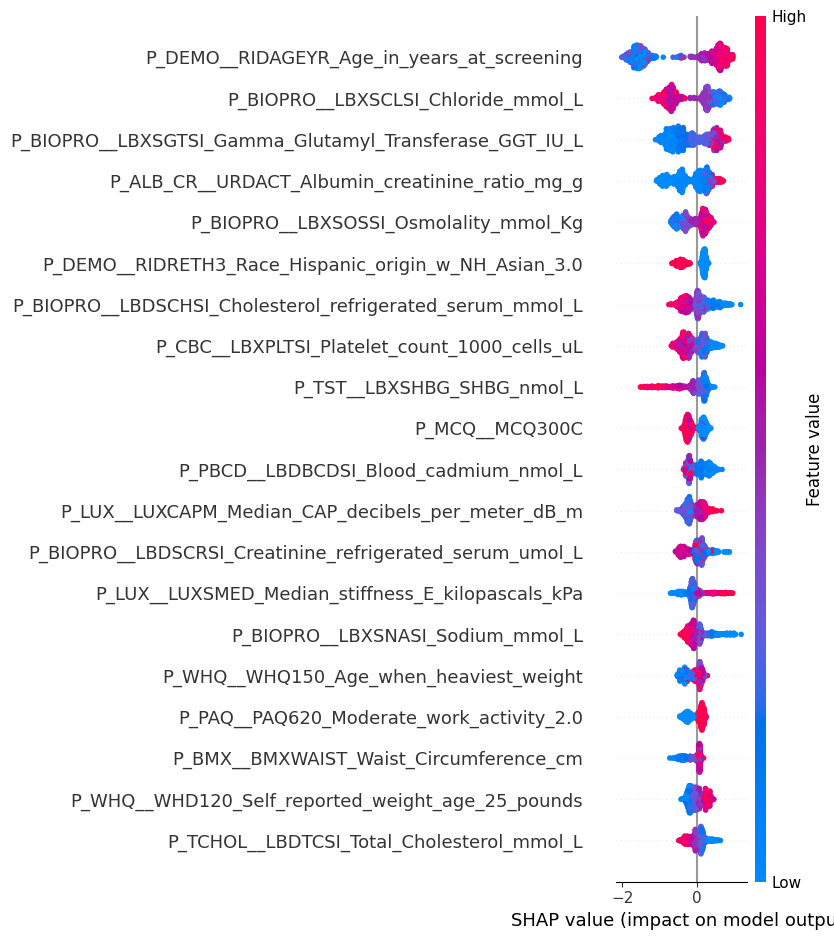

C:\Users\victo\AppData\Local\Temp\ipykernel_21924\233564440.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_rep, X_train_representatives_encoded, plot_type="bar", show=True)


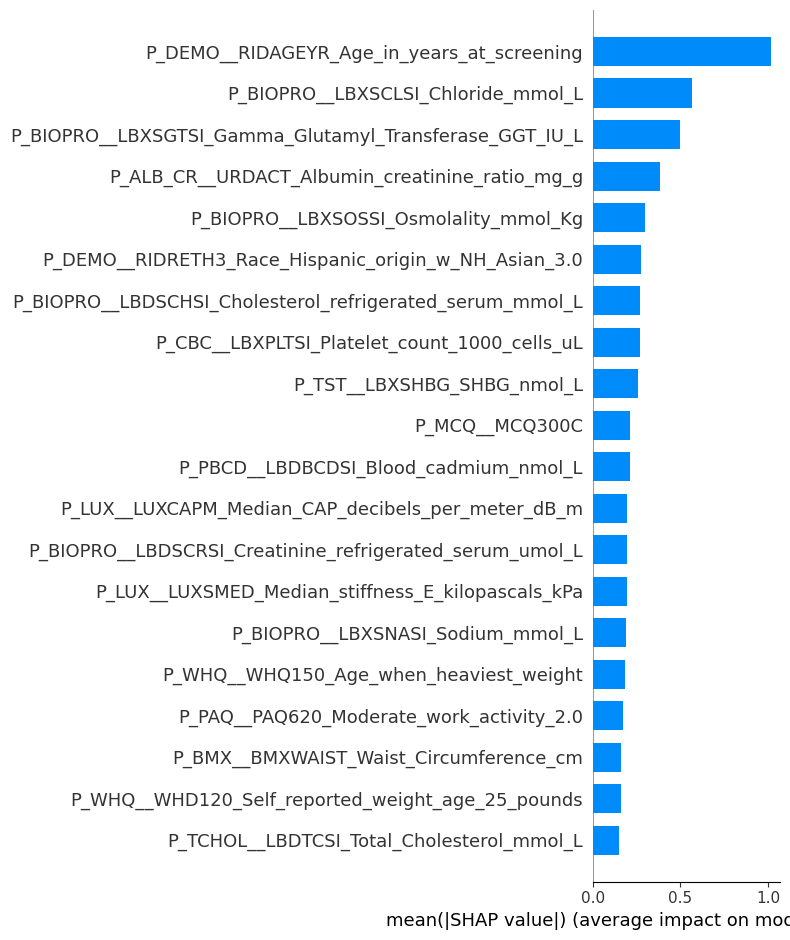

C:\Users\victo\AppData\Local\Temp\ipykernel_21924\233564440.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_interaction_values_rep,
c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this

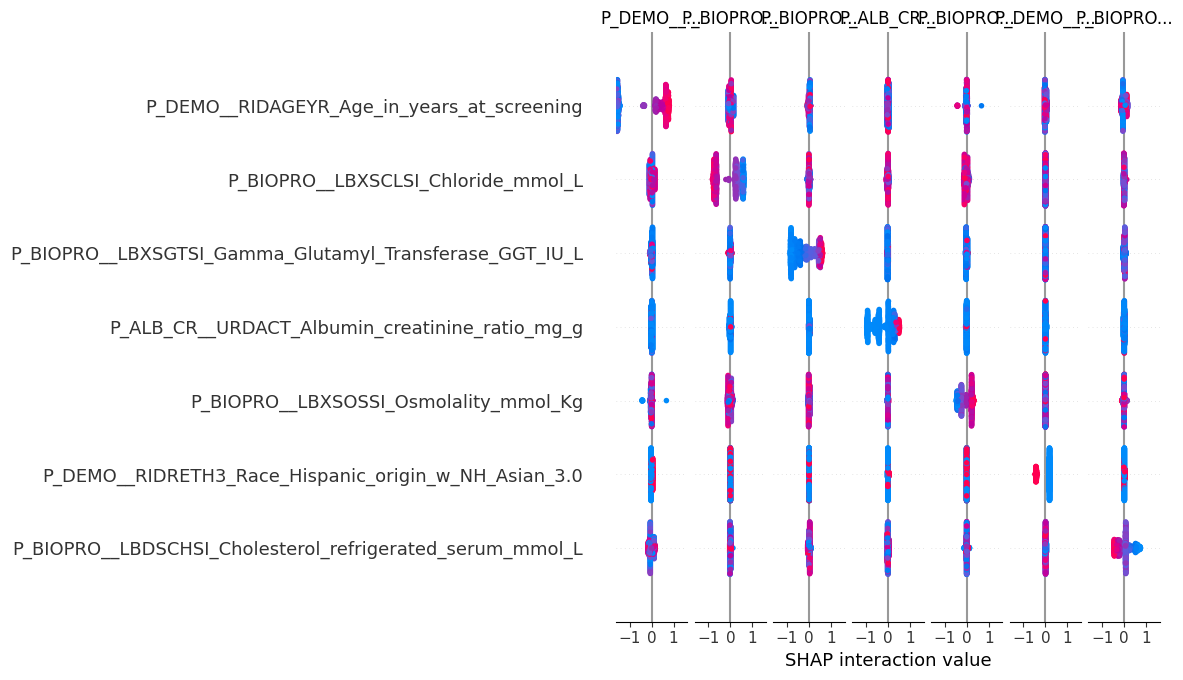

In [ ]:
import shap

# 1. initialize explainer with the proxy model
explainer_weighted = shap.TreeExplainer(xgb_weighted)

# 2. compute SHAP values (main effects) on the representative set
shap_values_rep = explainer_weighted.shap_values(X_train_representatives_encoded)

# 3. (optional, can be slow) interaction values
shap_interaction_values_rep = explainer_weighted.shap_interaction_values(X_train_representatives_encoded)

# 4. global summary plot (main effects)
shap.summary_plot(shap_values_rep, X_train_representatives_encoded, show=True)

# 5. bar plot (main effects)
shap.summary_plot(shap_values_rep, X_train_representatives_encoded, plot_type="bar", show=True)

# 6. (optional) interaction summary plot
shap.summary_plot(shap_interaction_values_rep,
                  X_train_representatives_encoded, show=True)

In [ ]:
# 1) Mean |interaction| over samples → (n_features, n_features)
interaction_matrix = np.abs(shap_interaction_values_rep).mean(axis=0)

# 2) Turn into a ranked list of feature pairs
cols = X_train_representatives_encoded.columns
pairs = []

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):  # upper triangle only
        pairs.append((cols[i], cols[j], interaction_matrix[i, j]))

interaction_df = pd.DataFrame(
    pairs,
    columns=["feature_1", "feature_2", "mean_abs_interaction"]
).sort_values("mean_abs_interaction", ascending=False)

print(interaction_df.head(20))      # top interactions
interaction_df.to_csv("shap_interactions.csv", index=False)

                                               feature_1  \
9748               P_BIOPRO__LBXSOSSI_Osmolality_mmol_Kg   
21            P_DEMO__RIDAGEYR_Age_in_years_at_screening   
31            P_DEMO__RIDAGEYR_Age_in_years_at_screening   
10            P_DEMO__RIDAGEYR_Age_in_years_at_screening   
7323                  P_BIOPRO__LBXSCLSI_Chloride_mmol_L   
8713   P_BIOPRO__LBXSGTSI_Gamma_Glutamyl_Transferase_...   
32459                                     P_MCQ__MCQ300C   
5901    P_BIOPRO__LBXSAL_Albumin_refrigerated_serum_g_dL   
7296                  P_BIOPRO__LBXSCLSI_Chloride_mmol_L   
19            P_DEMO__RIDAGEYR_Age_in_years_at_screening   
5527   P_BIOPRO__LBXSATSI_Alanine_Aminotransferase_AL...   
12779                P_BIOPRO__LBDSUASI_Uric_acid_umol_L   
11542  P_BIOPRO__LBDSCHSI_Cholesterol_refrigerated_se...   
19030       P_CBC__LBXPLTSI_Platelet_count_1000_cells_uL   
5513   P_BIOPRO__LBXSATSI_Alanine_Aminotransferase_AL...   
8029   P_BIOPRO__LBDSCRSI_Creatinine_ref